# Feature Extraction

This notebook creates window-based features from active power, identifies steady-state windows, visualizes representative operating periods, and exports the steady-state modelling dataset.

## Imports

In [1]:
import warnings

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

from helper_functions import (
    build_modelling_dataset,
    clean_signals,
    extract_operating_periods,
    extract_steady_states_by_threshold,
    extract_steady_states_from_windows,
    get_signal_df,
    load_signal_data,
    make_window_features,
    test_dbscan_eps,
    window_mean,
)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)

## Useful constants

In [2]:
DATA_FOLDER = Path("step_interpolation_10s/G2_relevant")
FIGURES_DIR = Path("figures")
PELT_TIMES_PATH = Path("pelt_times.csv")
MODEL_DATASET_PATH = Path("steady_state_model_dataset_1min.csv")

POWER_NAME = "Generator active power"
FIELD_CURRENT_NAME = "Exciter current"
NEEDLE_POSITION_NAME = "Total needle opening position"
INLET_PRESSURE_NAME = "Turbine inlet pressure"
VIBRATION_NAME = "DE vibration"
SPEED_NAME = "Rotational speed"
SETPOINT_NAME = "Set point"

WINDOW_SIZE = 6
DBSCAN_EPS = 0.11
DBSCAN_MIN_SAMPLES = 5
STD_THRESHOLD_QUANTILE = 0.975

## Load and Clean Data

In [3]:
dfs = load_signal_data(DATA_FOLDER)
dfs, invalid_summary = clean_signals(dfs, vibration_max_value=5)

invalid_summary

,Signal,Invalid values,Invalid [%]
0,Turbine inlet pressure,759,0.0578
1,DE bearing temperature,4,0.0003
2,DE bearing oil temperature,10,0.0008
3,DE vibration,3,0.0002


In [4]:
speed = get_signal_df(dfs, SPEED_NAME)
power = get_signal_df(dfs, POWER_NAME)
vibration = get_signal_df(dfs, VIBRATION_NAME)
field_current = get_signal_df(dfs, FIELD_CURRENT_NAME)
needle_position = get_signal_df(dfs, NEEDLE_POSITION_NAME)
inlet_pressure = get_signal_df(dfs, INLET_PRESSURE_NAME)
setpoint = get_signal_df(dfs, SETPOINT_NAME)

## Operating Periods and PELT Change Points

In [7]:
operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30,
)

operating_periods.head()

,start_time,end_time,n_samples
0,2024-06-01 00:00:00,2024-06-01 12:36:50,4542
1,2024-06-01 13:55:20,2024-06-03 07:38:30,15020
2,2024-06-03 08:01:10,2024-06-03 12:49:10,1729
3,2024-06-03 13:12:20,2024-06-03 17:54:30,1694
4,2024-06-03 19:08:40,2024-06-08 08:57:00,39531


In [8]:
pelt_df = pd.read_csv(PELT_TIMES_PATH)
pelt_df["Datetime"] = pd.to_datetime(pelt_df["Datetime"])
pelt_times = pelt_df["Datetime"].dropna().sort_values().tolist()

pelt_df.head()

,Datetime
0,2024-06-01 05:24:50
1,2024-06-01 13:57:50
2,2024-06-01 14:01:50
3,2024-06-01 14:05:30
4,2024-06-02 14:44:30


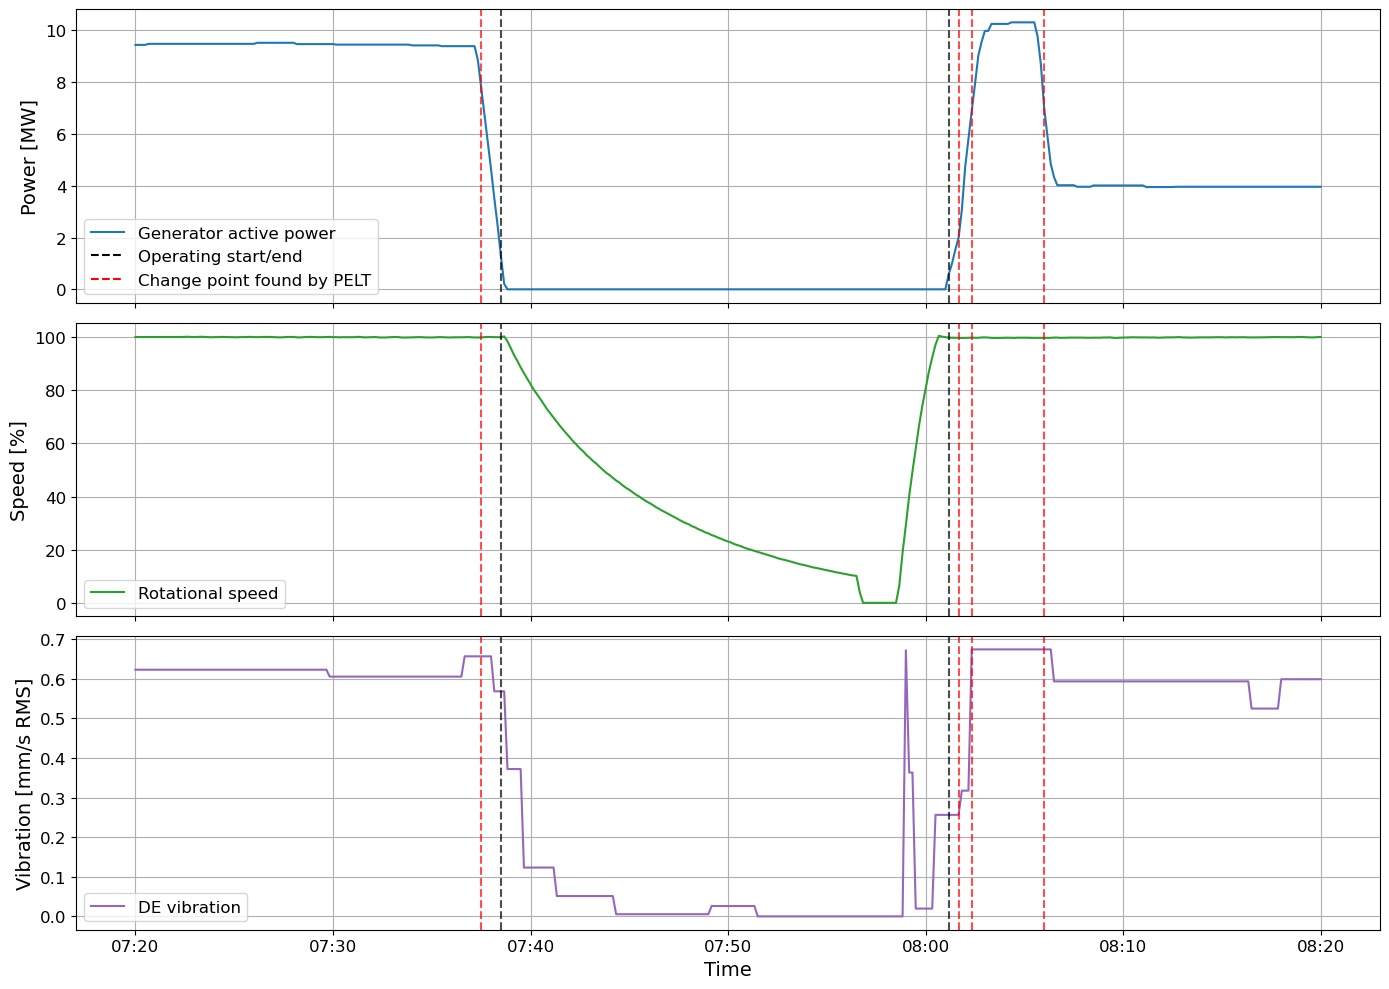

In [9]:
plot_start = pd.Timestamp("2024-06-03 07:20:00")
plot_end = plot_start + pd.Timedelta(hours=1)

power_plot = power[power["Datetime"].between(plot_start, plot_end)]
speed_plot = speed[speed["Datetime"].between(plot_start, plot_end)]
vibration_plot = vibration[vibration["Datetime"].between(plot_start, plot_end)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    power_plot["Datetime"],
    power_plot["signal"],
    label=POWER_NAME,
    color="tab:blue",
)
axes[1].plot(
    speed_plot["Datetime"],
    speed_plot["signal"],
    label=SPEED_NAME,
    color="tab:green",
)
axes[2].plot(
    vibration_plot["Datetime"],
    vibration_plot["signal"],
    label=VIBRATION_NAME,
    color="tab:purple",
)

axes[0].set_ylabel("Power [MW]", fontsize=14)
axes[1].set_ylabel("Speed [%]", fontsize=14)
axes[2].set_ylabel("Vibration [mm/s RMS]", fontsize=14)
axes[2].set_xlabel("Time", fontsize=14)

for _, period in operating_periods.iterrows():
    for time_point in [period["start_time"], period["end_time"]]:
        if plot_start <= time_point <= plot_end:
            for ax in axes:
                ax.axvline(time_point, color="black", linestyle="--", alpha=0.7)

for change_time in pelt_times:
    if plot_start <= change_time <= plot_end:
        for ax in axes:
            ax.axvline(change_time, color="red", linestyle="--", alpha=0.7)

axes[0].plot([], [], color="black", linestyle="--", label="Operating start/end")
axes[0].plot([], [], color="red", linestyle="--", label="Change point found by PELT")

for ax in axes:
    ax.grid(True)
    ax.legend(fontsize=12, loc="lower left")
    ax.tick_params(axis="both", labelsize=12)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "power_speed_vibration_pelt_breakpoints.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## DBSCAN Steady-State Exploration

In [10]:
windows = make_window_features(
    ref_df=power,
    operating_periods=operating_periods,
    window_size=WINDOW_SIZE,
    n_periods=20,
)

windows.sort_values(by="std_power", ascending=False).head()

,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx
25220,9,2024-06-19 06:45:20,2024-06-19 06:46:10,6.935000,2.045301,3294,3299
19315,7,2024-06-15 02:58:50,2024-06-15 02:59:40,7.436666,1.959368,47544,47549
20901,7,2024-06-16 05:24:50,2024-06-16 05:25:40,3.831667,1.938895,57060,57065
3541,2,2024-06-03 12:42:10,2024-06-03 12:43:00,6.725000,1.841609,1686,1691
15859,7,2024-06-12 17:22:50,2024-06-12 17:23:40,7.428333,1.835515,26808,26813


In [ ]:
eps_results = test_dbscan_eps(
    windows,
    eps_start=0.05,
    eps_stop=0.30,
    eps_step=0.02,
    min_samples=DBSCAN_MIN_SAMPLES,
)

eps_results

In [11]:
clustered_windows, steady_intervals = extract_steady_states_from_windows(
    windows,
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES,
)

steady_intervals.head()

,operating_period,interval_id,cluster,start_time,end_time,n_windows,mean_power,mean_std_power,min_power,max_power
0,0,1,0,2024-06-01 00:00:00,2024-06-01 05:09:50,310,9.424806,0.001467,9.360000,9.460000
1,0,3,0,2024-06-01 05:11:00,2024-06-01 12:36:50,446,10.198901,0.003481,9.710000,10.260000
2,1,5,0,2024-06-01 14:07:20,2024-06-01 14:10:10,3,10.182222,0.021999,10.133333,10.213333
3,1,6,1,2024-06-01 14:10:20,2024-06-01 14:11:10,1,10.170000,0.070000,10.170000,10.170000
4,1,7,0,2024-06-01 14:11:20,2024-06-02 14:44:10,1473,10.245133,0.001957,10.080000,10.331667


In [12]:
cluster_summary = (
    clustered_windows
    .groupby("cluster")
    .agg(
        n_windows=("cluster", "size"),
        mean_power=("mean_power", "mean"),
        mean_std_power=("std_power", "mean"),
        min_power=("mean_power", "min"),
        max_power=("mean_power", "max"),
    )
    .sort_index()
)

cluster_summary

,n_windows,mean_power,mean_std_power,min_power,max_power
cluster,,,,,
-1,305,5.296497,0.330812,0.636667,10.266666
0,49810,6.178946,0.003821,0.500000,10.410000
1,6,9.973611,0.068618,9.755000,10.170000
2,5,1.610667,0.062257,1.380000,1.755000


In [13]:
base_colors = [
    "tab:green",
    "tab:orange",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]

clusters = sorted(clustered_windows["cluster"].dropna().unique())
cluster_colors = {-1: "tab:blue"}
normal_clusters = [cluster for cluster in clusters if cluster != -1]

for i, cluster in enumerate(normal_clusters):
    cluster_colors[cluster] = base_colors[i % len(base_colors)]

outlier_handle = mpatches.Patch(
    color=cluster_colors[-1],
    label="Outliers",
)

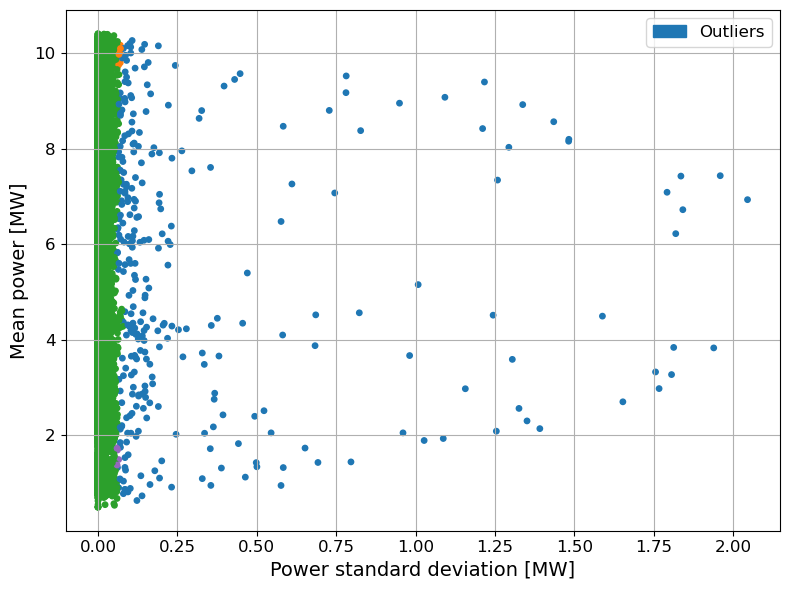

In [14]:
point_colors = clustered_windows["cluster"].map(cluster_colors)

plt.figure(figsize=(8, 6))
plt.scatter(
    clustered_windows["std_power"],
    clustered_windows["mean_power"],
    c=point_colors,
    s=15,
)

plt.legend(handles=[outlier_handle], fontsize=12, loc="upper right")
plt.xlabel("Power standard deviation [MW]", fontsize=14)
plt.ylabel("Mean power [MW]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "dbscan_feature_space.png", dpi=300, bbox_inches="tight")
plt.show()

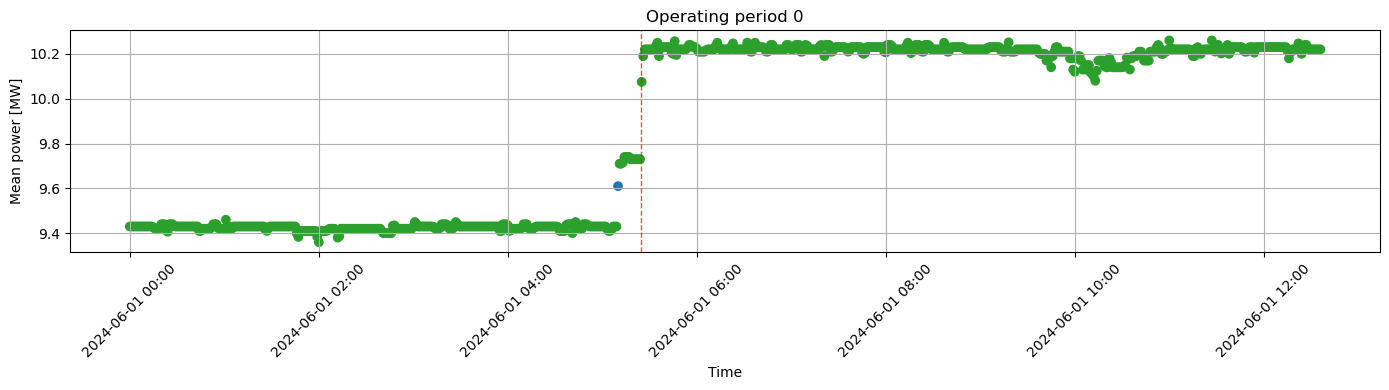

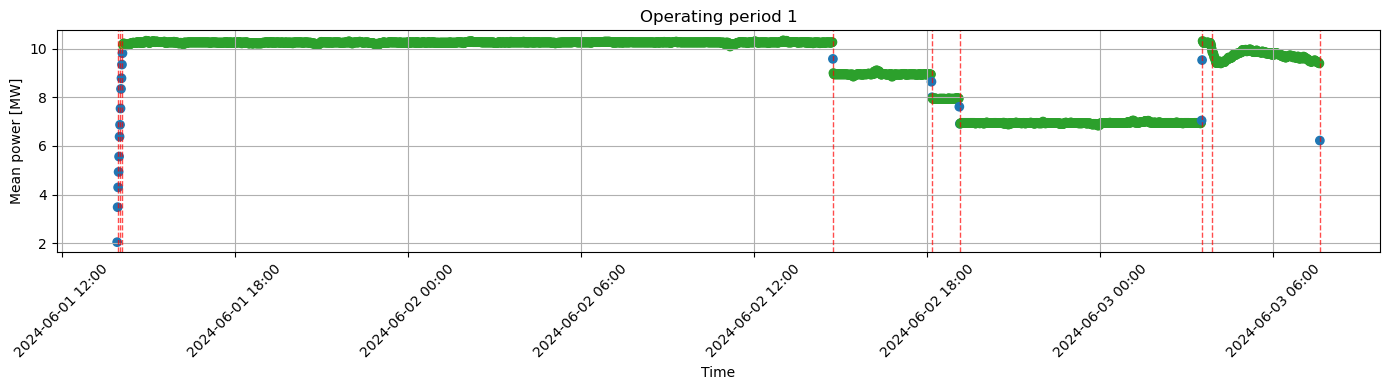

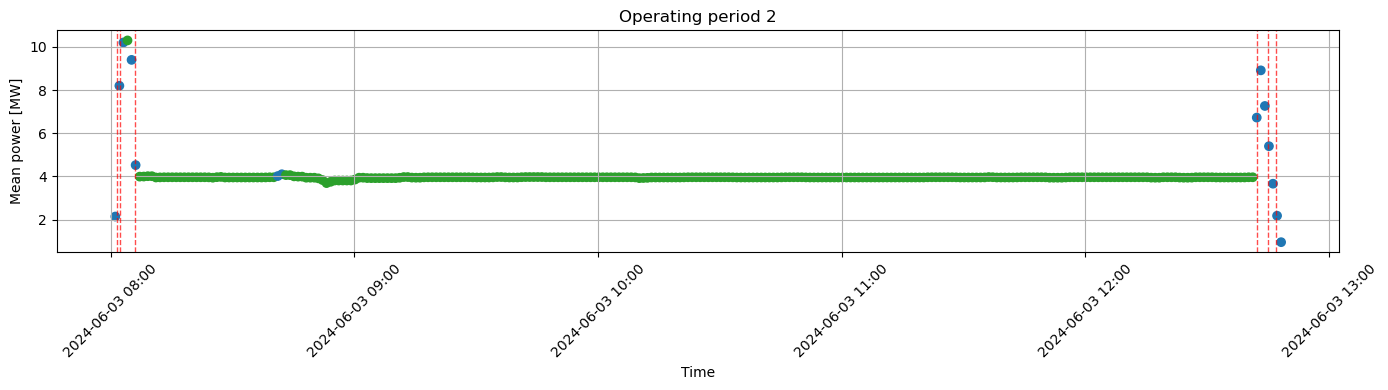

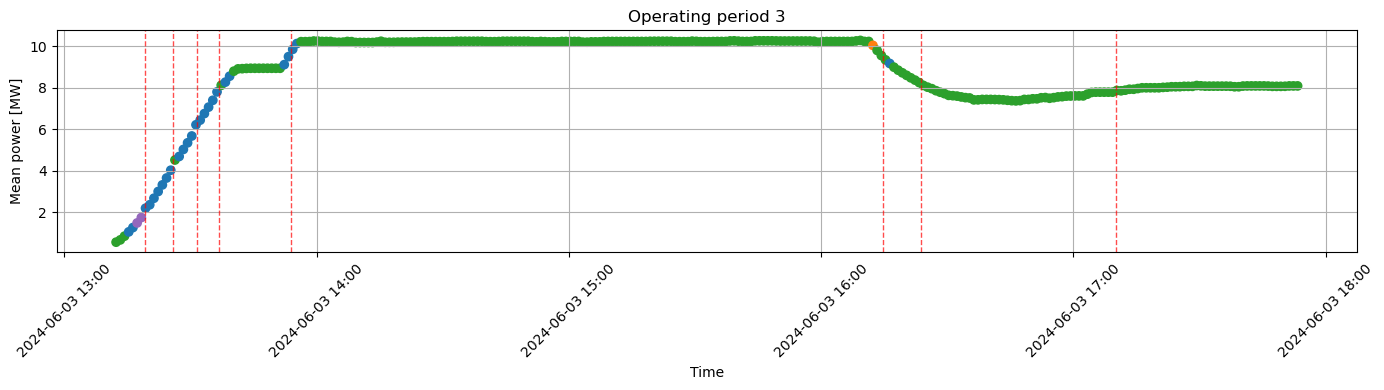

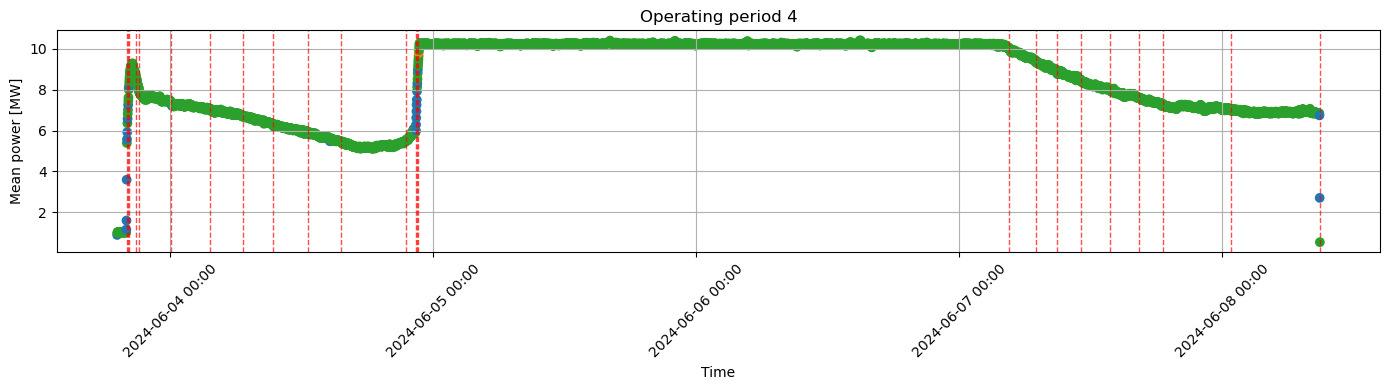

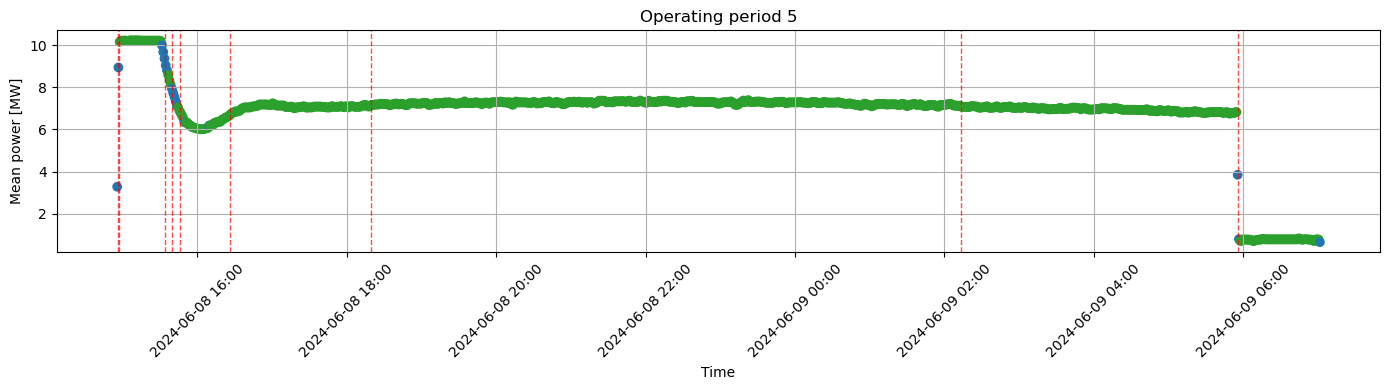

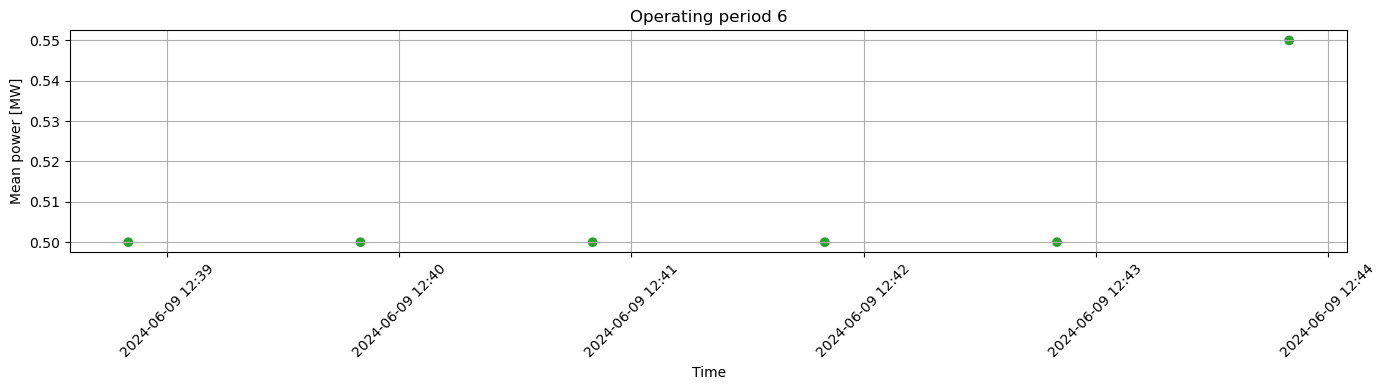

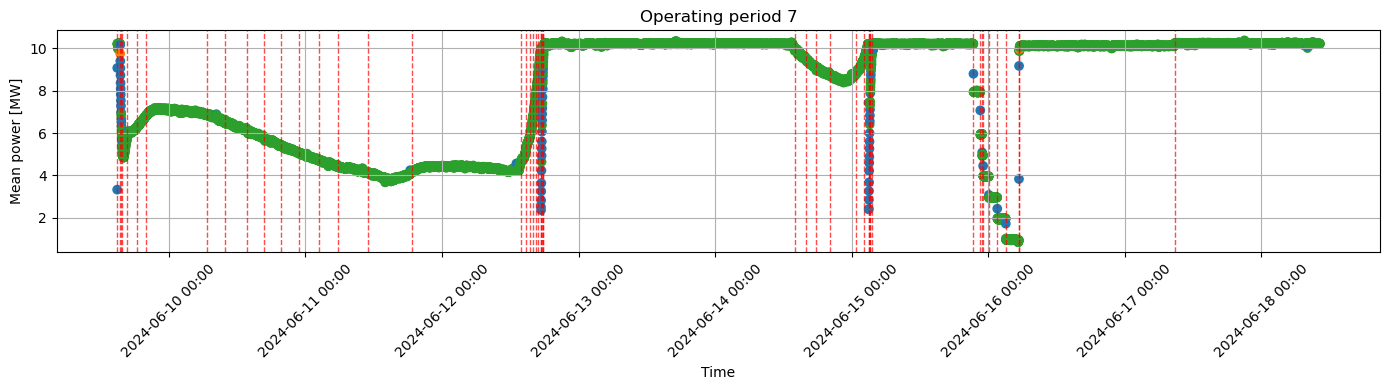

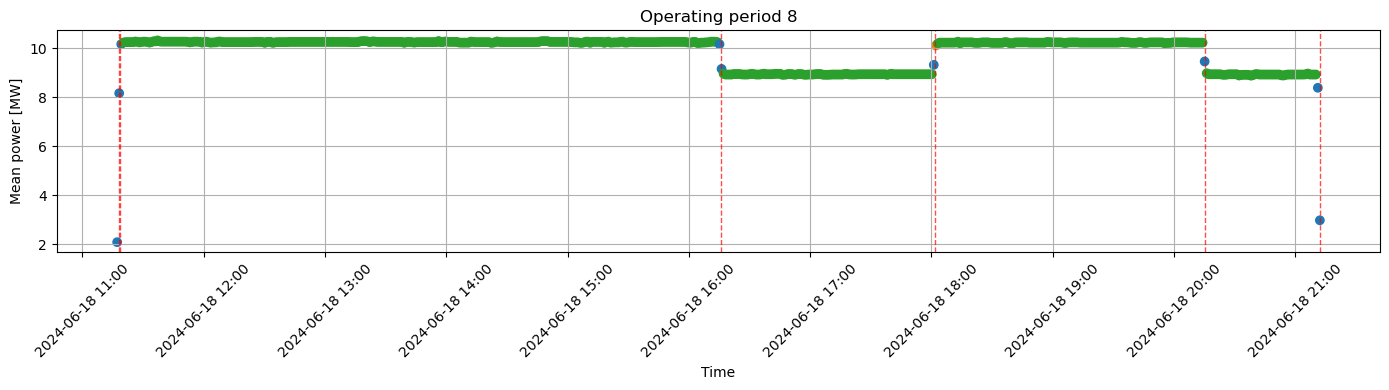

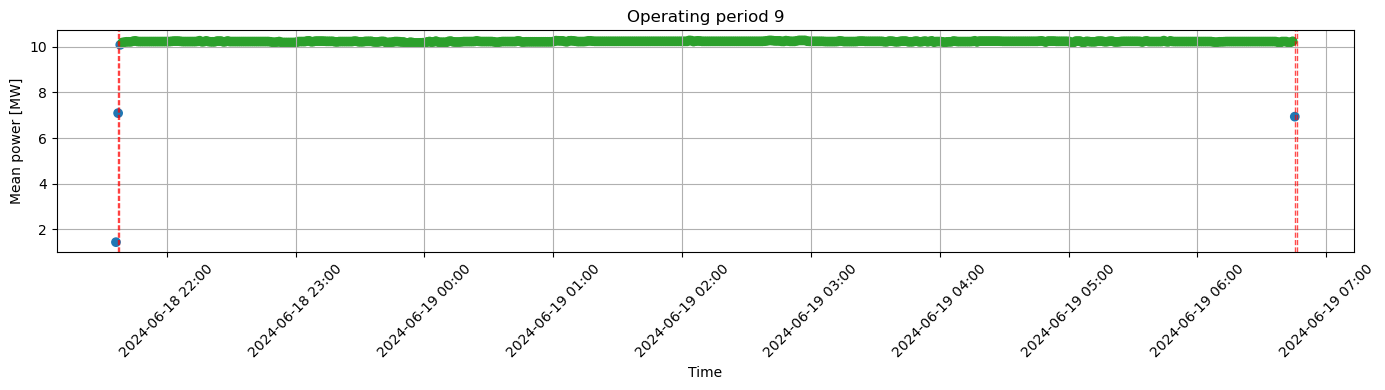

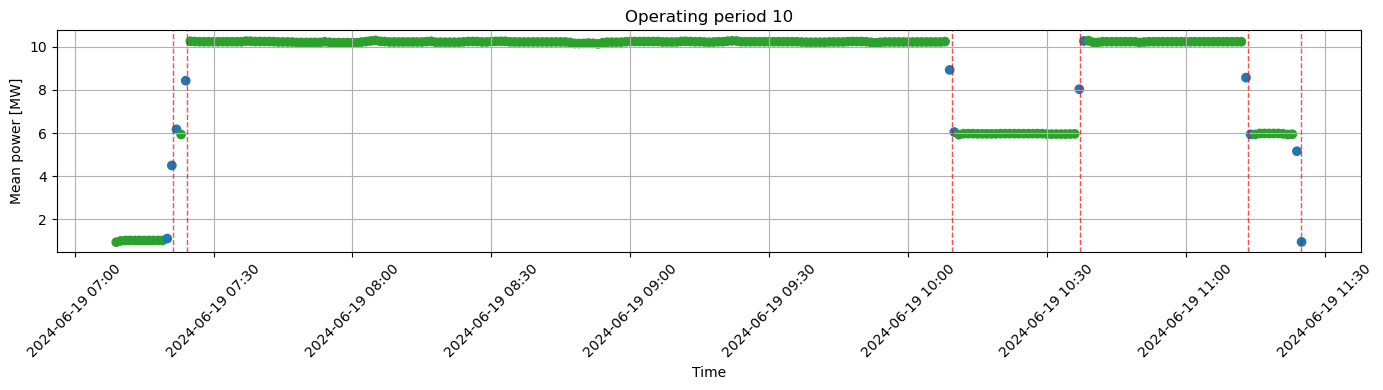

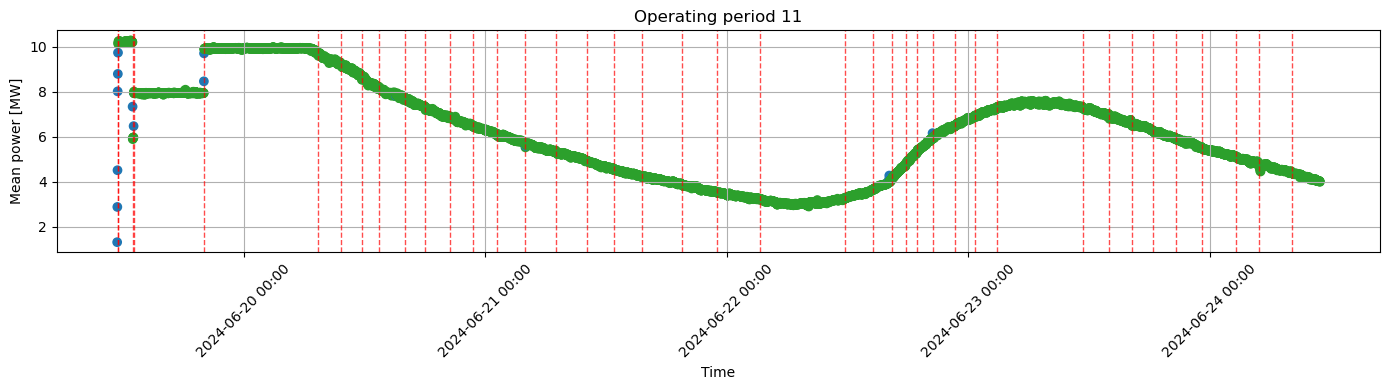

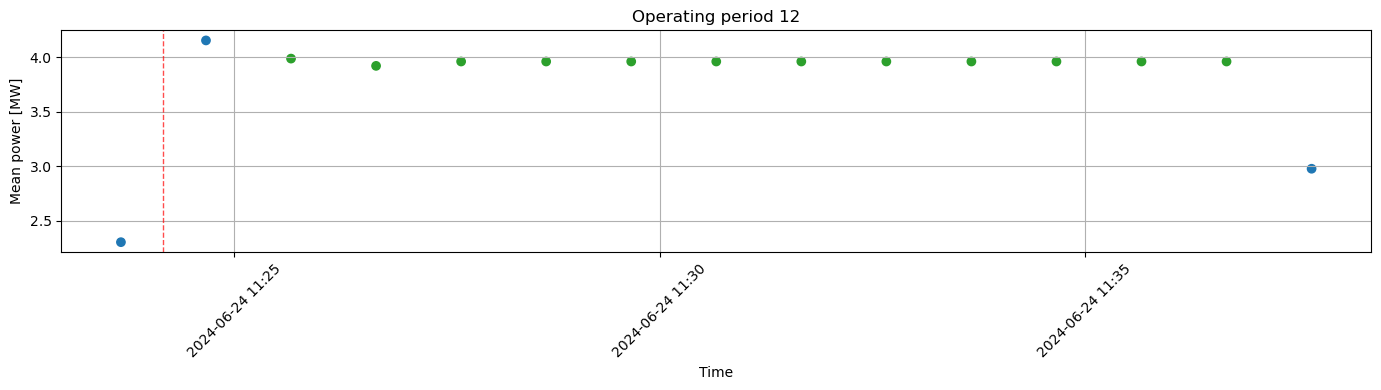

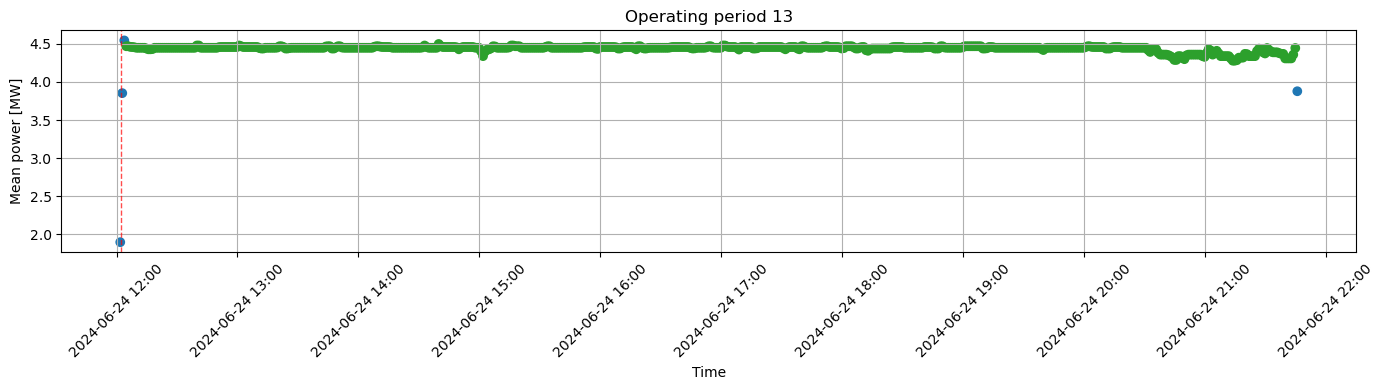

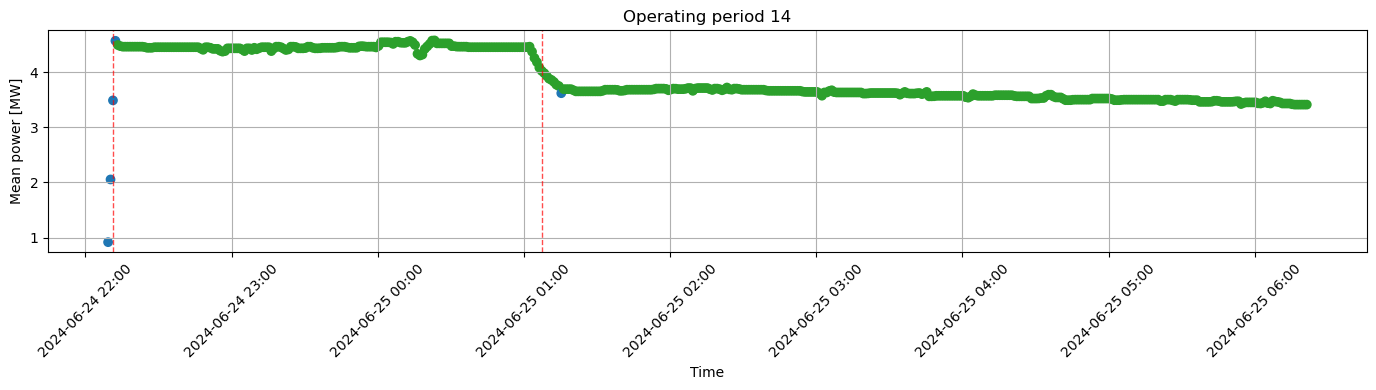

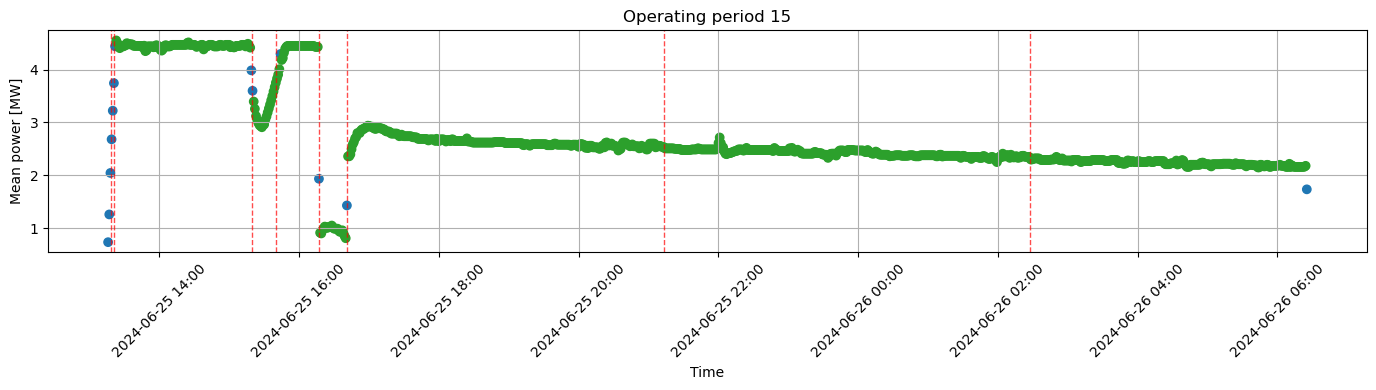

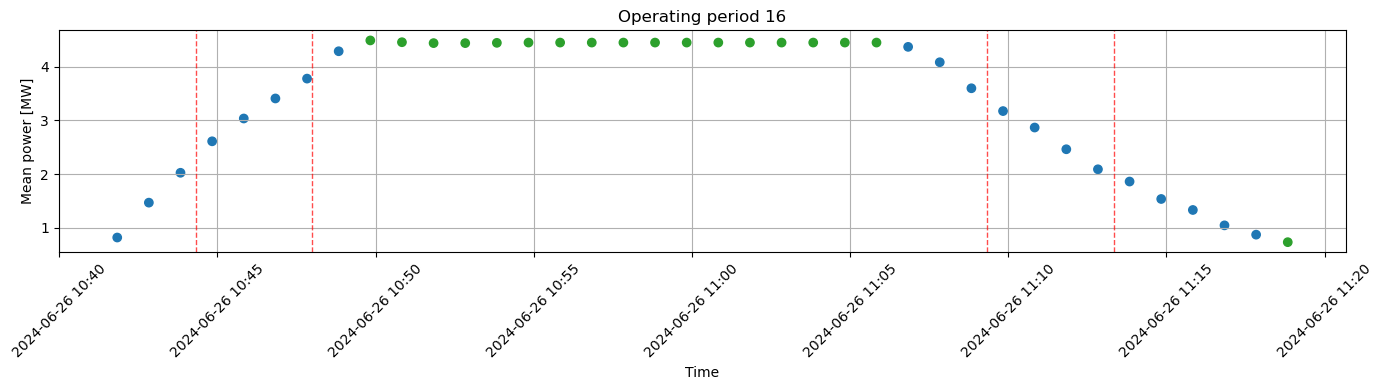

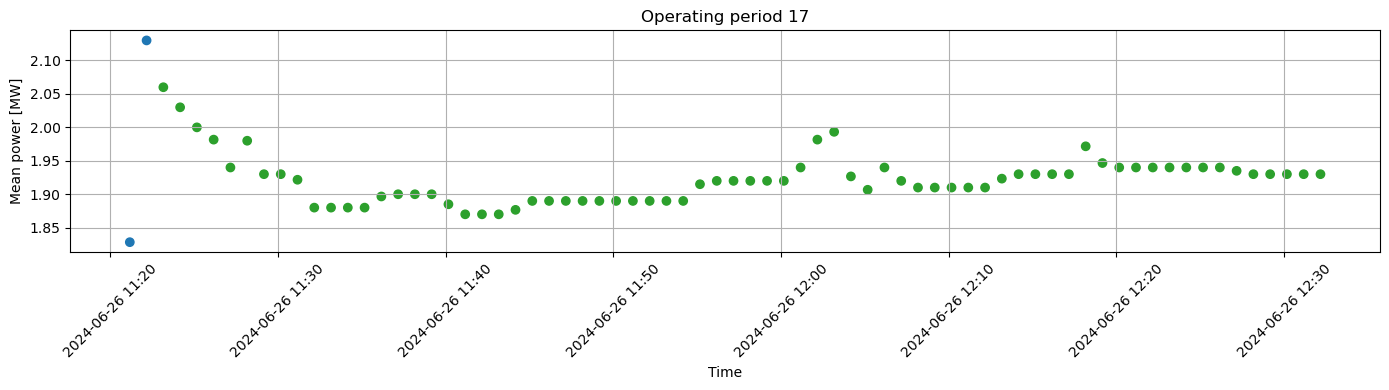

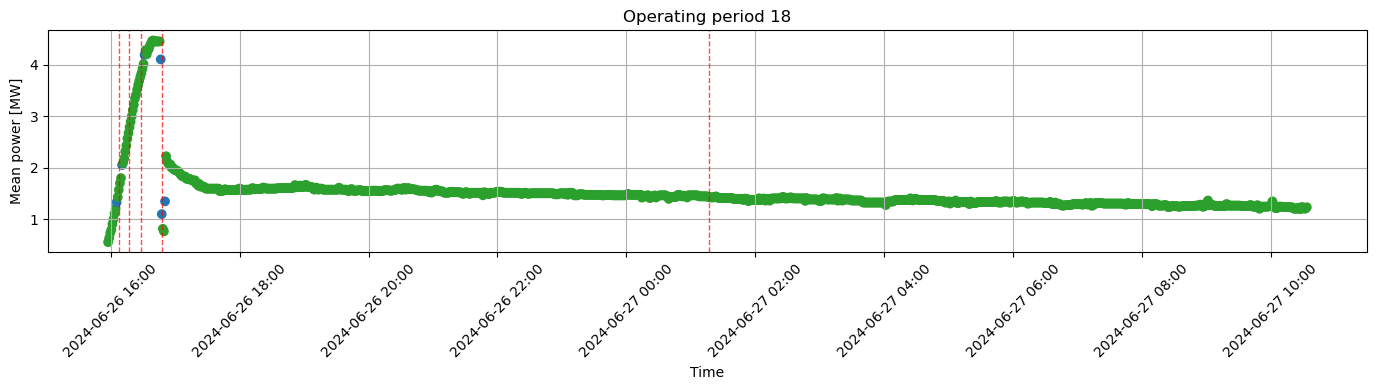

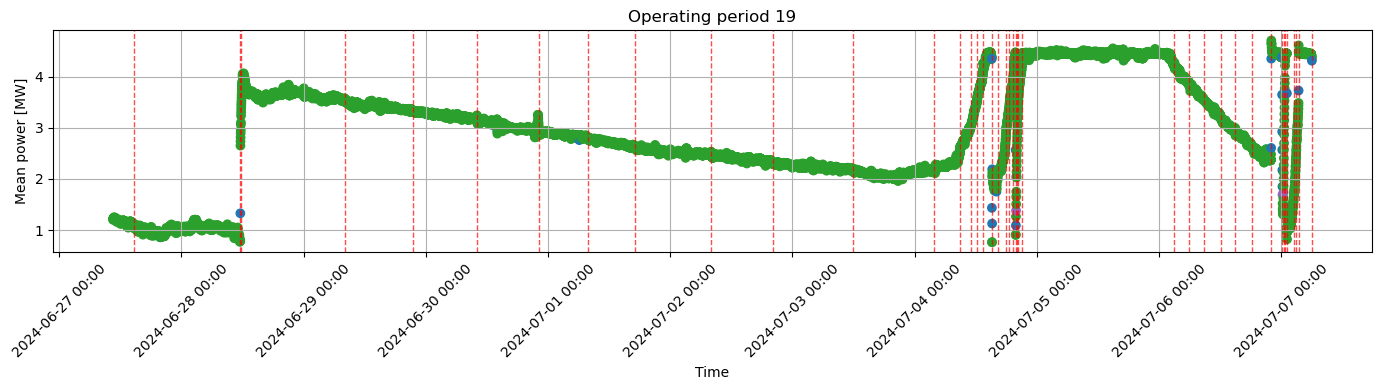

In [15]:
for operating_period in sorted(clustered_windows["operating_period"].unique()):
    period_windows = clustered_windows[
        clustered_windows["operating_period"] == operating_period
    ]

    period_start = period_windows["start_time"].min()
    period_end = period_windows["end_time"].max()
    point_colors = period_windows["cluster"].map(cluster_colors)

    plt.figure(figsize=(14, 4))
    plt.scatter(
        period_windows["start_time"],
        period_windows["mean_power"],
        c=point_colors,
    )

    for change_time in pelt_times:
        if period_start <= change_time <= period_end:
            plt.axvline(
                change_time,
                color="red",
                linestyle="--",
                linewidth=1,
                alpha=0.7,
            )

    plt.xlabel("Time")
    plt.ylabel("Mean power [MW]")
    plt.title(f"Operating period {operating_period}")
    plt.grid(True)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

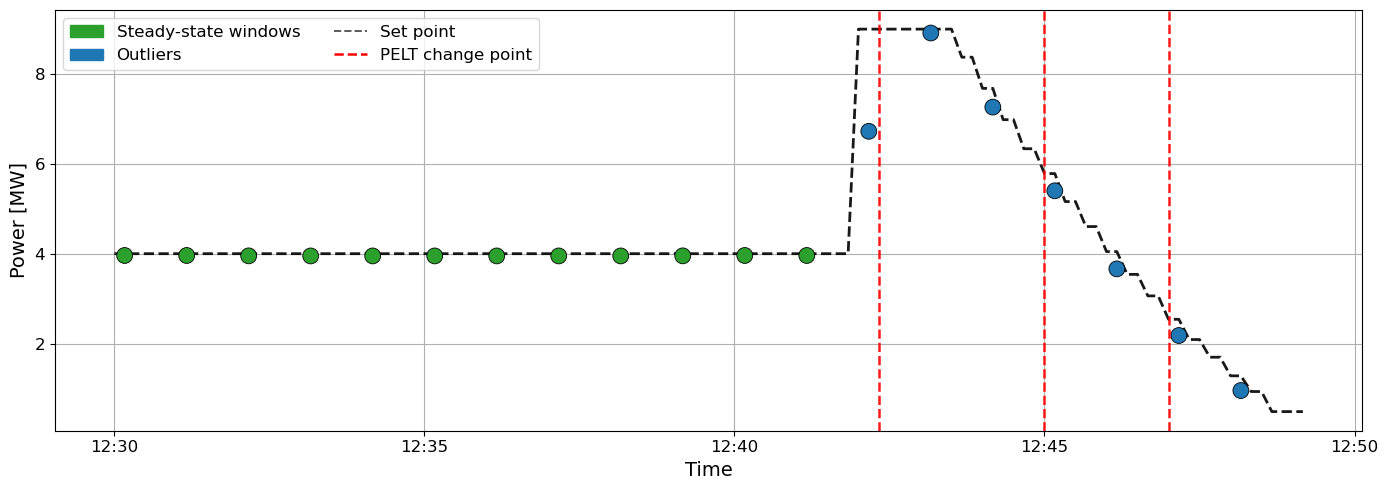

In [16]:
operating_period = 2
period = operating_periods.loc[operating_period]
start_time = pd.Timestamp("2024-06-03 12:30:00")
end_time = period["end_time"]

plot_windows = clustered_windows[
    (clustered_windows["operating_period"] == operating_period)
    & (clustered_windows["start_time"] >= start_time)
    & (clustered_windows["start_time"] <= end_time)
].copy()

plot_setpoint = setpoint[
    setpoint["Datetime"].between(start_time, end_time)
].copy()

point_colors = plot_windows["cluster"].map(cluster_colors)
steady_handle = mpatches.Patch(color="tab:green", label="Steady-state windows")
outlier_handle = mpatches.Patch(color=cluster_colors[-1], label="Outliers")
setpoint_handle = plt.Line2D(
    [],
    [],
    color="black",
    linestyle="--",
    linewidth=1.4,
    alpha=0.65,
    label="Set point",
)
pelt_handle = plt.Line2D(
    [],
    [],
    color="red",
    linestyle="--",
    linewidth=1.8,
    label="PELT change point",
)

plt.figure(figsize=(14, 5))
plt.plot(
    plot_setpoint["Datetime"],
    plot_setpoint["signal"],
    color="black",
    linestyle="--",
    linewidth=2.0,
    alpha=0.9,
    zorder=2,
)
plt.scatter(
    plot_windows["start_time"],
    plot_windows["mean_power"],
    c=point_colors,
    s=130,
    edgecolors="black",
    linewidths=0.6,
    zorder=3,
)

for change_time in pelt_times:
    if start_time <= change_time <= end_time:
        plt.axvline(
            change_time,
            color="red",
            linestyle="--",
            linewidth=1.8,
            alpha=0.9,
            zorder=5,
        )

plt.xlabel("Time", fontsize=14)
plt.ylabel("Power [MW]", fontsize=14)
plt.grid(True)
plt.tick_params(axis="both", labelsize=12)
plt.legend(
    handles=[steady_handle, outlier_handle, setpoint_handle, pelt_handle],
    fontsize=12,
    loc="upper left",
    ncol=2,
    frameon=True,
)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / f"operating_period_{operating_period}_steady_state_windows.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Threshold-Based Steady-State Extraction

In [17]:
windows_all = make_window_features(
    ref_df=power,
    operating_periods=operating_periods,
    window_size=WINDOW_SIZE,
)

windows_all.head()

,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,9.429999,0.0,0,5
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,9.429999,0.0,6,11
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,9.429999,0.0,12,17
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,9.429999,0.0,18,23
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,9.429999,0.0,24,29


In [18]:
std_threshold = windows_all["std_power"].quantile(STD_THRESHOLD_QUANTILE)
windows_threshold, steady_intervals_all = extract_steady_states_by_threshold(
    windows_all,
    std_threshold=std_threshold,
)

windows_threshold.head()

,operating_period,start_time,end_time,mean_power,std_power,start_idx,end_idx,is_steady,interval_id
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,9.429999,0.0,0,5,True,1
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,9.429999,0.0,6,11,True,1
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,9.429999,0.0,12,17,True,1
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,9.429999,0.0,18,23,True,1
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,9.429999,0.0,24,29,True,1


In [20]:
print("Window size [samples]:", WINDOW_SIZE)
print("Std threshold [MW]:", std_threshold.round(4))
print("Operating periods with windows:", windows_all["operating_period"].nunique())
print("Total operating periods:", len(operating_periods))
print("All windows:", len(windows_threshold))
print("Steady windows:", windows_threshold["is_steady"].sum())
print("Steady windows [%]:", round(windows_threshold["is_steady"].mean() * 100, 2))
print("Steady intervals:", len(steady_intervals_all))

Window size [samples]: 6
Std threshold [MW]: 0.033
Operating periods with windows: 59
Total operating periods: 59
All windows: 212374
Steady windows: 207065
Steady windows [%]: 97.5
Steady intervals: 3209


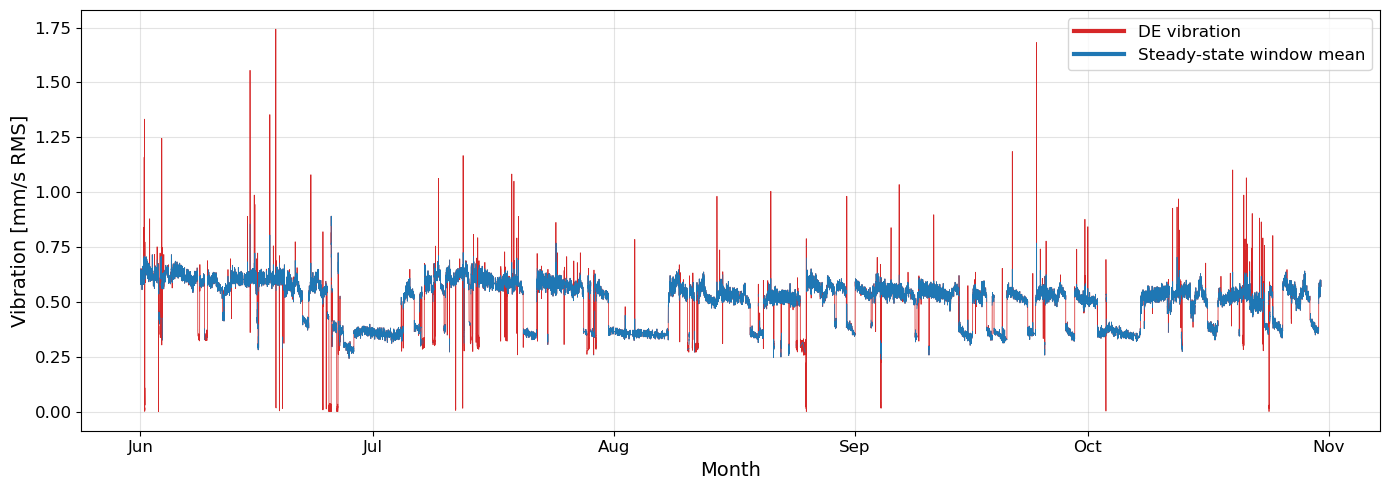

In [21]:
vibration_plot = (
    vibration
    .dropna(subset=["Datetime", "signal"])
    .sort_values("Datetime")
)
plot_windows = windows_threshold.copy()

plot_windows["mid_time"] = (
    plot_windows["start_time"]
    + (plot_windows["end_time"] - plot_windows["start_time"]) / 2
)
plot_windows["mean_vibration"] = window_mean(vibration_plot, plot_windows)
plot_windows.loc[~plot_windows["is_steady"], "mean_vibration"] = float("nan")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    vibration_plot["Datetime"],
    vibration_plot["signal"],
    linewidth=0.55,
    color="tab:red",
    label="DE vibration",
)
ax.plot(
    plot_windows["mid_time"],
    plot_windows["mean_vibration"],
    linewidth=0.55,
    color="tab:blue",
    label="Steady-state window mean",
)

ax.set_xlabel("Month", fontsize=14)
ax.set_ylabel("Vibration [mm/s RMS]", fontsize=14)
ax.grid(True, alpha=0.35)
ax.legend(
    handles=[
        Line2D([0], [0], color="tab:red", linewidth=3.0, label="DE vibration"),
        Line2D([0], [0], color="tab:blue", linewidth=3.0, label="Steady-state window mean"),
    ],
    fontsize=12,
    loc="upper right",
    frameon=True,
    handlelength=3.0,
)
ax.tick_params(axis="both", labelsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "vibration_steady_window_mean_full.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Export Modelling Dataset

In [22]:
model_1min = build_modelling_dataset(
    windows_threshold,
    needle_position_df=needle_position,
    exciter_current_df=field_current,
    inlet_pressure_df=inlet_pressure,
    vibration_df=vibration,
)

model_1min.head()

,operating_period,start_time,end_time,is_steady,interval_id,power,needle_position,exciter_current,inlet_pressure,de_vibration
0,0,2024-06-01 00:00:00,2024-06-01 00:00:50,True,1,9.429999,75.339462,6.948219,3826.189043,0.586103
1,0,2024-06-01 00:01:00,2024-06-01 00:01:50,True,1,9.429999,74.975650,6.953729,3826.189043,0.618846
2,0,2024-06-01 00:02:00,2024-06-01 00:02:50,True,1,9.429999,75.124611,6.959528,3826.189043,0.618846
3,0,2024-06-01 00:03:00,2024-06-01 00:03:50,True,1,9.429999,75.124611,6.954519,3826.189043,0.618846
4,0,2024-06-01 00:04:00,2024-06-01 00:04:50,True,1,9.429999,75.124611,6.950508,3826.189043,0.618846


In [23]:
model_1min.to_csv(MODEL_DATASET_PATH, index=False)